Рабочая папка: d:\MASTER\Term4\2\Seminar_GHADEER\Lab03\LAB3

Запись: eeg1, ID = 1
ID                                                             1
EEG file                                                    eeg1
Diagnosis                                 mild/moderate asphyxia
Number of Reviewers Annotating Seizure                         3
Name: 0, dtype: object

Частота дискретизации: 256.0 Гц
Длительность записи: 6993.0 с
Всего каналов: 21
Каналы: ['EEG Fp1-REF', 'EEG Fp2-REF', 'EEG F3-REF', 'EEG F4-REF', 'EEG C3-REF', 'EEG C4-REF', 'EEG P3-REF', 'EEG P4-REF', 'EEG O1-REF', 'EEG O2-REF', 'EEG F7-REF', 'EEG F8-REF', 'EEG T3-REF', 'EEG T4-REF', 'EEG T5-REF', 'EEG T6-REF', 'EEG Fz-REF', 'EEG Cz-REF', 'EEG Pz-REF', 'ECG EKG-REF', 'Resp Effort-REF']
EEG-каналов: 19
Не-EEG каналы: ['ECG EKG-REF', 'Resp Effort-REF']

Найденные приступные интервалы (первые 10):
 start_sec  end_sec  duration_sec
       328      447           120
      1005     1109           105
      6603     6700           

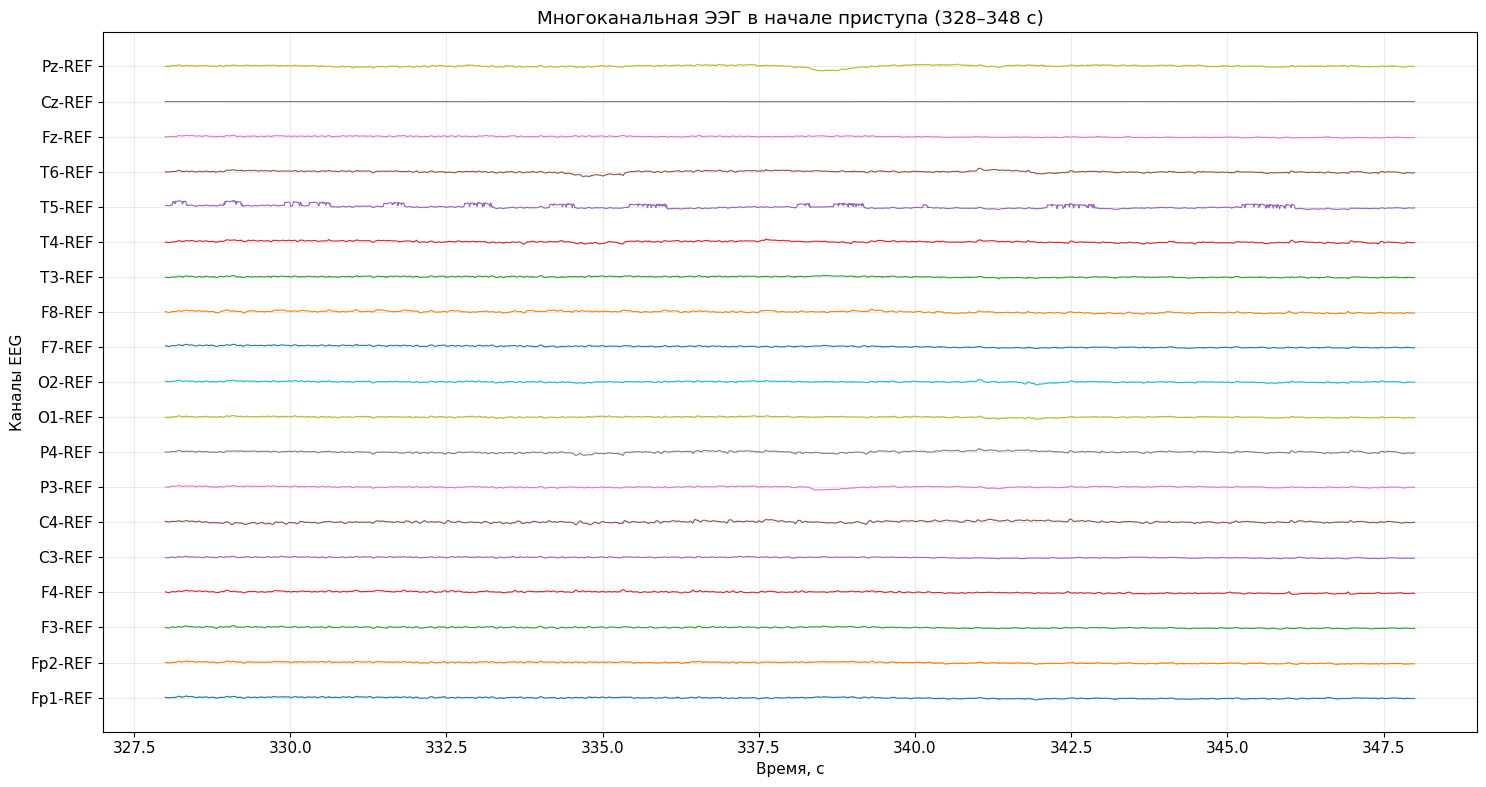

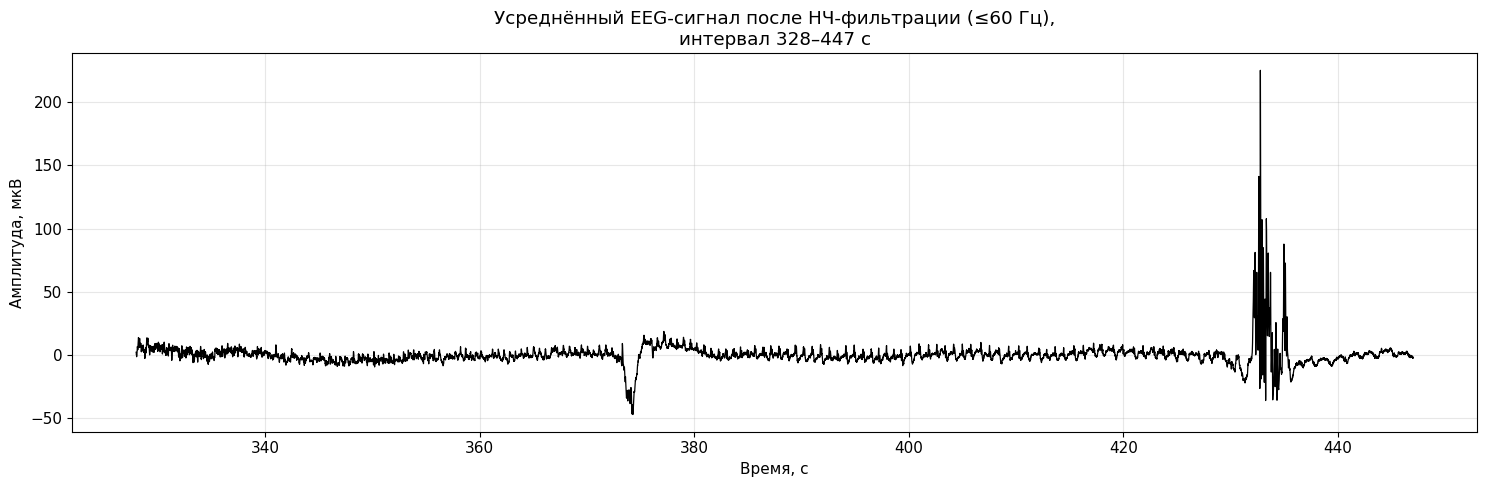


Доминирующая частота по средней спектральной мощности: 0.50 Гц


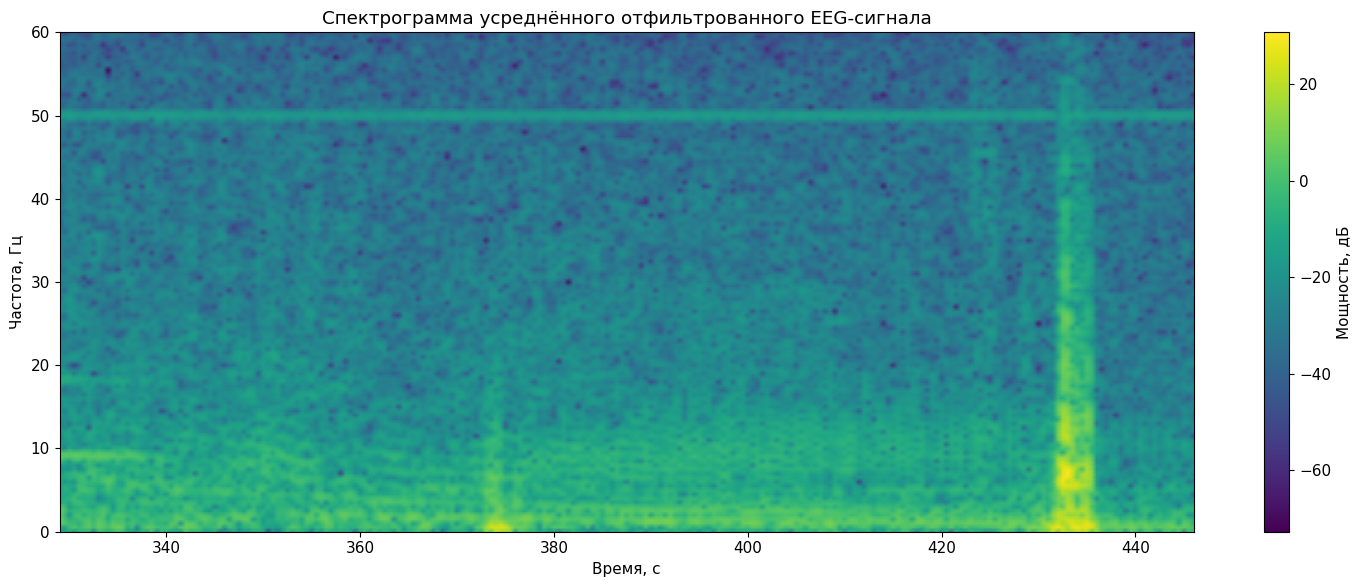

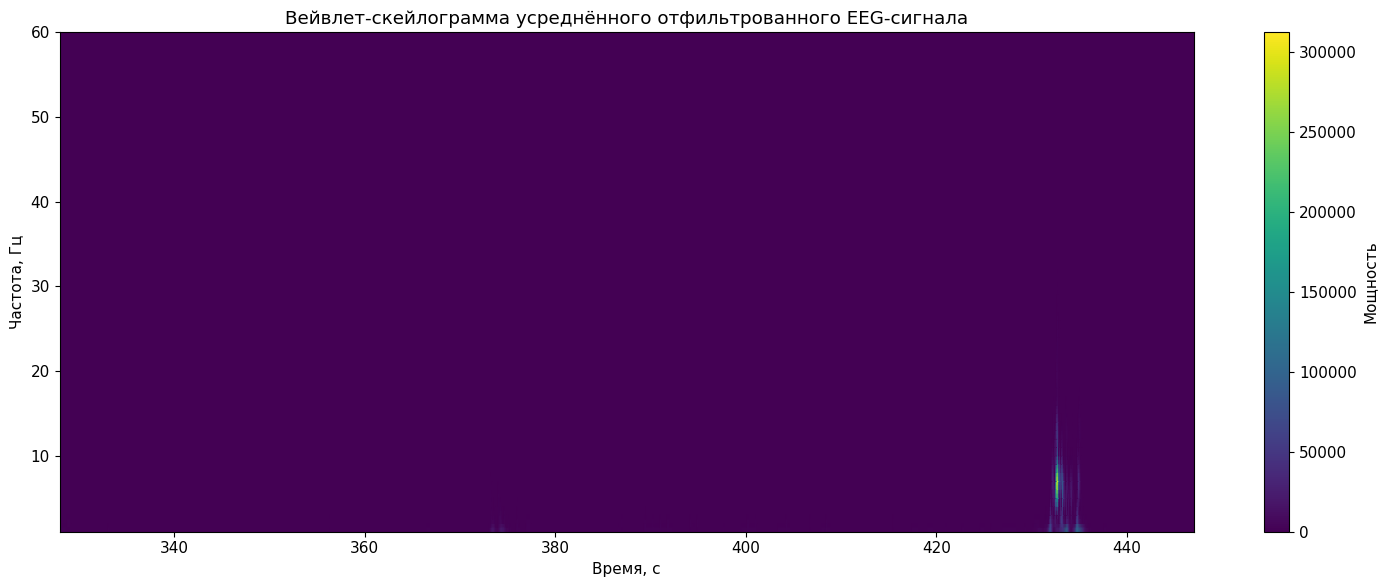


Пиковая мощность по частотным диапазонам (вейвлет-анализ):
        Диапазон  Время максимума, с  Пиковая мощность
  delta (1–4 Гц)          434.859375      76781.216285
  theta (4–8 Гц)          432.757812     209195.625363
 alpha (8–13 Гц)          432.757812     136698.918593
 beta (13–30 Гц)          432.750000      11903.946626
gamma (30–60 Гц)          432.765625        245.423430

Метрики эксперимента:
record_name  record_id  sampling_rate_hz  duration_sec  total_channels  eeg_channels  chosen_seizure_start_sec  chosen_seizure_end_sec  chosen_seizure_duration_sec  dominant_frequency_hz  filtered_signal_mean_uv  filtered_signal_std_uv  filtered_signal_min_uv  filtered_signal_max_uv
       eeg1          1             256.0        6993.0              21            19                       328                     447                          120                    0.5                 0.105557                8.838822              -47.112576              225.114279

Файлы сохранены в 

In [7]:
# -*- coding: utf-8 -*-
"""
Лабораторная работа №3.
Исследование скрытых характеристик сигналов электроэнцефалографии.
Запись: eeg1.edf
"""

import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.signal as signal
import mne

# Настройка графиков
plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["font.size"] = 11

# Рабочая папка – там же, где лежит ноутбук и файлы данных
WORK_DIR = Path.cwd()
print("Рабочая папка:", WORK_DIR)

# Пути к необходимым файлам
edf_path = WORK_DIR / "eeg1.edf"
ann_path = WORK_DIR / "annotations_2017_C.csv"
clinical_path = WORK_DIR / "clinical_information.csv"

# Проверяем наличие файлов
for f in [edf_path, ann_path, clinical_path]:
    if not f.exists():
        raise FileNotFoundError(f"Не найден файл: {f}")

# ------------------------------------------------------------
# 1. Загрузка клинической информации и аннотаций
# ------------------------------------------------------------
clinical_df = pd.read_csv(clinical_path)
annotations_df = pd.read_csv(ann_path)

# Идентификатор записи eeg1
record_name = "eeg1"
record_row = clinical_df.loc[clinical_df["EEG file"] == record_name]
if record_row.empty:
    raise ValueError(f"Запись {record_name} не найдена в clinical_information.csv")
record_row = record_row.iloc[0]
record_id = int(record_row["ID"])
print(f"\nЗапись: {record_name}, ID = {record_id}")
print(record_row[["ID", "EEG file", "Diagnosis", "Number of Reviewers Annotating Seizure"]])

# Извлечение столбца аннотаций для данного ID
if str(record_id) not in annotations_df.columns:
    raise KeyError(f"Столбец {record_id} отсутствует в файле аннотаций")
ann_series = annotations_df[str(record_id)].fillna(0).astype(int)

# ------------------------------------------------------------
# 2. Функция выделения непрерывных интервалов с пометкой "1" (приступ)
# ------------------------------------------------------------
def get_intervals(binary_series):
    intervals = []
    in_run = False
    start = None
    for i, value in enumerate(binary_series):
        if value == 1 and not in_run:
            start = i
            in_run = True
        elif value == 0 and in_run:
            intervals.append((start, i - 1, i - start))
            in_run = False
    if in_run:
        intervals.append((start, len(binary_series) - 1, len(binary_series) - start))
    return intervals

# ------------------------------------------------------------
# 3. Чтение EDF-файла
# ------------------------------------------------------------
raw = mne.io.read_raw_edf(edf_path, preload=True, verbose="ERROR")
sfreq = raw.info["sfreq"]                     # частота дискретизации
duration_sec = raw.n_times / sfreq           # длительность записи
print(f"\nЧастота дискретизации: {sfreq} Гц")
print(f"Длительность записи: {duration_sec:.1f} с")
print(f"Всего каналов: {len(raw.ch_names)}")
print("Каналы:", raw.ch_names)

# Разделение каналов
eeg_channels = [ch for ch in raw.ch_names if ch.startswith("EEG")]
non_eeg_channels = [ch for ch in raw.ch_names if not ch.startswith("EEG")]
print(f"EEG-каналов: {len(eeg_channels)}")
print("Не-EEG каналы:", non_eeg_channels)

# Ограничиваем аннотационный ряд длительностью записи
ann_series = ann_series.iloc[:int(duration_sec)].reset_index(drop=True)

# ------------------------------------------------------------
# 4. Определение всех приступных интервалов и выбор основного
# ------------------------------------------------------------
all_intervals = get_intervals(ann_series.values)
intervals_df = pd.DataFrame(all_intervals, columns=["start_sec", "end_sec", "duration_sec"])
intervals_df = intervals_df.sort_values(["duration_sec", "start_sec"],
                                        ascending=[False, True]).reset_index(drop=True)

print("\nНайденные приступные интервалы (первые 10):")
print(intervals_df.head(10).to_string(index=False))

if intervals_df.empty:
    raise RuntimeError("Для данной записи не найдено ни одного размеченного приступа!")

seizure_start, seizure_end, seizure_duration = intervals_df.iloc[0]
print(f"\nВыбран основной интервал: {seizure_start}–{seizure_end} с "
      f"(длительность {seizure_duration} с)")

# ------------------------------------------------------------
# 5. График многоканальной ЭЭГ в начале приступа (первые 20 с)
# ------------------------------------------------------------
raw_eeg = raw.copy().pick(eeg_channels)
data_uv = raw_eeg.get_data() * 1e6          # перевод из В в мкВ

plot_start_sec = int(seizure_start)
plot_end_sec = min(int(seizure_start) + 20, int(seizure_end))

start_idx = int(plot_start_sec * sfreq)
end_idx = int(plot_end_sec * sfreq)

segment = data_uv[:, start_idx:end_idx]
time_segment = np.arange(start_idx, end_idx) / sfreq

offset_step = 300   # разнесение каналов по вертикали
plt.figure(figsize=(15, 8))
for i in range(segment.shape[0]):
    plt.plot(time_segment, segment[i] + i * offset_step, linewidth=0.8)

plt.yticks(
    [i * offset_step for i in range(len(eeg_channels))],
    [ch.replace("EEG ", "") for ch in eeg_channels]
)
plt.xlabel("Время, с")
plt.ylabel("Каналы EEG")
plt.title(f"Многоканальная ЭЭГ в начале приступа ({plot_start_sec}–{plot_end_sec} с)")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(WORK_DIR / "eeg1_multichannel_seizure.png", dpi=300, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# 6. Усреднение всех EEG-каналов в один сигнал
# ------------------------------------------------------------
avg_signal_uv = data_uv.mean(axis=0)

# ------------------------------------------------------------
# 7. Низкочастотная фильтрация (Баттерворт 4-го порядка, срез 60 Гц)
# ------------------------------------------------------------
sos = signal.butter(4, 60, btype="lowpass", fs=sfreq, output="sos")
avg_signal_filt_uv = signal.sosfiltfilt(sos, avg_signal_uv)

# ------------------------------------------------------------
# 8. Выделение приступного интервала отфильтрованного сигнала
# ------------------------------------------------------------
seizure_start_idx = int(seizure_start * sfreq)
seizure_end_idx = int(seizure_end * sfreq)

avg_seizure_uv = avg_signal_filt_uv[seizure_start_idx:seizure_end_idx]
time_seizure = np.arange(seizure_start_idx, seizure_end_idx) / sfreq

# График усреднённого отфильтрованного сигнала во время приступа
plt.figure(figsize=(15, 5))
plt.plot(time_seizure, avg_seizure_uv, color="black", linewidth=0.9)
plt.xlabel("Время, с")
plt.ylabel("Амплитуда, мкВ")
plt.title(f"Усреднённый EEG-сигнал после НЧ-фильтрации (≤60 Гц),\n"
          f"интервал {seizure_start}–{seizure_end} с")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(WORK_DIR / "eeg1_avg_filtered_seizure.png", dpi=300, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# 9. Спектрограмма (STFT)
# ------------------------------------------------------------
frequencies, times_spec, Sxx = signal.spectrogram(
    avg_seizure_uv,
    fs=sfreq,
    window="hann",
    nperseg=512,
    noverlap=384,
    scaling="density",
    mode="psd"
)

# Оставляем только частоты до 60 Гц
freq_mask = frequencies <= 60
frequencies = frequencies[freq_mask]
Sxx = Sxx[freq_mask, :]

mean_psd = Sxx.mean(axis=1)
dominant_freq = frequencies[np.argmax(mean_psd)]
print(f"\nДоминирующая частота по средней спектральной мощности: {dominant_freq:.2f} Гц")

plt.figure(figsize=(15, 6))
plt.pcolormesh(times_spec + seizure_start, frequencies,
               10 * np.log10(Sxx + 1e-12), shading="gouraud")
plt.colorbar(label="Мощность, дБ")
plt.xlabel("Время, с")
plt.ylabel("Частота, Гц")
plt.title("Спектрограмма усреднённого отфильтрованного EEG-сигнала")
plt.ylim(0, 60)
plt.tight_layout()
plt.savefig(WORK_DIR / "eeg1_spectrogram.png", dpi=300, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# 10. Вейвлет-скейлограмма (комплексный Morlet)
# ------------------------------------------------------------
freqs = np.arange(1, 61)                    # анализируемый диапазон частот
n_cycles = np.maximum(freqs / 2, 2)         # число циклов вейвлета

power = mne.time_frequency.tfr_array_morlet(
    avg_seizure_uv[np.newaxis, np.newaxis, :],
    sfreq=sfreq,
    freqs=freqs,
    n_cycles=n_cycles,
    output="power",
    decim=2,                                # децимация для ускорения
    n_jobs=1,
    verbose="ERROR"
)[0, 0]

time_wavelet = time_seizure[::2]             # временная ось с учётом децимации

plt.figure(figsize=(15, 6))
plt.pcolormesh(time_wavelet, freqs, power, shading="gouraud")
plt.colorbar(label="Мощность")
plt.xlabel("Время, с")
plt.ylabel("Частота, Гц")
plt.title("Вейвлет-скейлограмма усреднённого отфильтрованного EEG-сигнала")
plt.ylim(1, 60)
plt.tight_layout()
plt.savefig(WORK_DIR / "eeg1_scalogram.png", dpi=300, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# 11. Количественный анализ пиков по частотным диапазонам
# ------------------------------------------------------------
band_definitions = {
    "delta (1–4 Гц)": (1, 4),
    "theta (4–8 Гц)": (4, 8),
    "alpha (8–13 Гц)": (8, 13),
    "beta (13–30 Гц)": (13, 30),
    "gamma (30–60 Гц)": (30, 60),
}

band_peaks = []
for band_name, (f_low, f_high) in band_definitions.items():
    mask = (freqs >= f_low) & (freqs < f_high)
    band_series = power[mask].mean(axis=0)
    peak_idx = int(np.argmax(band_series))
    band_peaks.append({
        "Диапазон": band_name,
        "Время максимума, с": float(time_wavelet[peak_idx]),
        "Пиковая мощность": float(band_series[peak_idx])
    })

band_peaks_df = pd.DataFrame(band_peaks)
print("\nПиковая мощность по частотным диапазонам (вейвлет-анализ):")
print(band_peaks_df.to_string(index=False))

# ------------------------------------------------------------
# 12. Сохранение сводных метрик
# ------------------------------------------------------------
summary_metrics = pd.DataFrame([{
    "record_name": record_name,
    "record_id": record_id,
    "sampling_rate_hz": float(sfreq),
    "duration_sec": float(duration_sec),
    "total_channels": int(len(raw.ch_names)),
    "eeg_channels": int(len(eeg_channels)),
    "chosen_seizure_start_sec": int(seizure_start),
    "chosen_seizure_end_sec": int(seizure_end),
    "chosen_seizure_duration_sec": int(seizure_duration),
    "dominant_frequency_hz": float(dominant_freq),
    "filtered_signal_mean_uv": float(avg_seizure_uv.mean()),
    "filtered_signal_std_uv": float(avg_seizure_uv.std()),
    "filtered_signal_min_uv": float(avg_seizure_uv.min()),
    "filtered_signal_max_uv": float(avg_seizure_uv.max())
}])

summary_metrics.to_csv(WORK_DIR / "experiment3_metrics.csv", index=False)
intervals_df.to_csv(WORK_DIR / "seizure_intervals_eeg1.csv", index=False)
band_peaks_df.to_csv(WORK_DIR / "wavelet_band_peaks.csv", index=False)

print("\nМетрики эксперимента:")
print(summary_metrics.to_string(index=False))
print("\nФайлы сохранены в рабочую папку:")
print("- eeg1_multichannel_seizure.png")
print("- eeg1_avg_filtered_seizure.png")
print("- eeg1_spectrogram.png")
print("- eeg1_scalogram.png")
print("- experiment3_metrics.csv")
print("- seizure_intervals_eeg1.csv")
print("- wavelet_band_peaks.csv")